# 07 · Stability diagnostics and energy parity

## What this is

The work that made the endpoint pipeline trustworthy. Without it, every number in
notebooks 03–06 would rest on a pipeline that ran to completion while propagating
waters with no charge and no Lennard-Jones interaction.

Three investigations, all reproduced here from retained JSON:

1. **Energy parity** — is the Sire/Loch system the same physics as Ludovic's
   direct-OpenMM system? (Answer: to 0.001 kJ/mol out of 8.9 × 10⁸.)
2. **The UVT2 incident** — a five-way isolation that located the failure in the
   *topology handoff*, not in NPT, the timestep, minimisation, restraints or
   constraint drift.
3. **The UVT1 fix, twice** — job 61723 showed the first fix did not work even
   though UVT1 itself ran clean; job 61724 confirmed the revised one.

## The diagnostic discipline, stated once

- **Parity audit first.** Before any stochastic trace, open the failing stage in
  Ludovic's original external script and compare it line by line with the code
  actually reached from the submitted wrapper. Follow executable statements, not
  comments. Treat an omitted, reordered or numerically different Ludovic
  operation as the leading hypothesis. Only go deeper when that finds nothing.
- **Fixed seed, one changed variable, JSON snapshots at move/MD boundaries.**
- **Stop before MD when the post-move force is already unsafe.** The first MD step
  only turns a bad force into NaNs; the information is in the state *before* it.
- **`result.json` is atomically replaced after every record**, so a killed job
  still yields a usable trace.
- **Unsafe states and invalid handoffs exit non-zero.** Slurm completion alone
  cannot mask a diagnostic failure.

## Workflow

0. Configuration
1. Energy parity — Ludovic/OpenMM vs Sire/Loch at identical coordinates
2. The UVT2 incident — five-way isolation
3. The mechanism, read off the trace
4. The UVT1 fix — job 61723 (failed) and 61724 (confirmed)
5. Native-MD control ladder
6. Result interpretation table
7. Recap

---
## 0 · Configuration

In [1]:
from pathlib import Path

PROJECT_1 = Path("/home/moshe/intern_projects/project_1")
OUTPUT = PROJECT_1 / "output"
SCRIPTS = PROJECT_1 / "scripts"

# Energy-parity comparisons at identical coordinates.
ENERGY_JSONS = {
    "ludovic_combined (min 20)": OUTPUT / "ludovic_combined_energy_comparison_min20.json",
    "ludovic_combined (min 0)":  OUTPUT / "ludovic_combined_energy_comparison.json",
    "ludovic_combined unique":   OUTPUT / "ludovic_combined_unique_energy_comparison.json",
    "native AMBER":              OUTPUT / "native_energy_comparison.json",
    "OpenFF development path":   OUTPUT / "energy_comparison.json",
}

# The UVT2 five-way isolation (Slurm job 61716) and the two UVT1 jobs.
UVT2_DIR = PROJECT_1 / "uvt2-stability-61716"
UVT1_JOBS = {
    "61723 (first fix)":   PROJECT_1 / "uvt1-stability-61723",
    "61724 (revised fix)": PROJECT_1 / "uvt1-stability-61724",
}

print(f"output dir : {OUTPUT}  (exists={OUTPUT.is_dir()})")
print(f"uvt2 job   : {UVT2_DIR}  (exists={UVT2_DIR.is_dir()})")
for k, v in UVT1_JOBS.items():
    print(f"uvt1 {k:<20} exists={v.is_dir()}")

output dir : /home/moshe/intern_projects/project_1/output  (exists=True)
uvt2 job   : /home/moshe/intern_projects/project_1/uvt2-stability-61716  (exists=True)
uvt1 61723 (first fix)    exists=True
uvt1 61724 (revised fix)  exists=True


In [2]:
import json
import math
from pathlib import Path

import numpy as np

try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False

---
## 1 · Energy parity — identical coordinates, two constructions

The question: does rebuilding Ludovic's system through Sire/Loch give the **same
potential** as his direct OpenMM construction?

Method: build both from the same AMBER input, minimise the direct-OpenMM system by
a fixed number of iterations, then evaluate **both** at those identical
coordinates. The Cα positional restraint is zero at its own reference coordinates
and is omitted from both, so it cannot mask a difference.

`compare_ludovic_loch_energy.py` also reports the Sire energy *before* the
compatibility adjustment, which is what makes the adjustment auditable rather
than a fudge: you can see exactly what it changed.

In [3]:
# ── Read every energy comparison ─────────────────────────────────────────────
rows = []
for label, path in ENERGY_JSONS.items():
    if not path.is_file():
        rows.append((label, None, None, None, None, None, "absent"))
        continue
    d = json.loads(path.read_text())
    direct = d["direct_openmm"]
    rows.append((
        label,
        direct["system"]["particles"],
        direct["system"]["constraints"],
        direct["energy"]["total_kj_mol"],
        d.get("adjusted_total_delta_kj_mol"),
        d.get("adjusted_total_relative_delta"),
        "",
    ))

W = 116
print("╔" + "═" * W + "╗")
print("║ " + f"{'ENERGY PARITY AT IDENTICAL COORDINATES':^{W - 1}}"[:W - 1] + "║")
print("╠" + "═" * W + "╣")
hdr = (f"{'comparison':<28}{'particles':>11}{'constraints':>13}"
       f"{'direct total kJ/mol':>24}{'delta kJ/mol':>18}{'relative':>16}")
print("║ " + hdr.ljust(W - 1) + "║")
print("╟" + "─" * W + "╢")
for label, n, c, tot, delta, rel, note in rows:
    if n is None:
        print("║ " + f"{label:<28}{note}".ljust(W - 1) + "║")
        continue
    d_s = f"{delta:+.6f}" if delta is not None else "-"
    r_s = f"{rel:+.3e}" if rel is not None else "-"
    line = f"{label:<28}{n:>11,}{c:>13,}{tot:>24,.4f}{d_s:>18}{r_s:>16}"
    print("║ " + line.ljust(W - 1) + "║")
print("╚" + "═" * W + "╝")

╔════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                       ENERGY PARITY AT IDENTICAL COORDINATES                                       ║
╠════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╣
║ comparison                    particles  constraints     direct total kJ/mol      delta kJ/mol        relative     ║
╟────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╢
║ ludovic_combined (min 20)        64,112       60,230        889,204,400.9958         -0.000975      -1.097e-12     ║
║ ludovic_combined (min 0)         64,112       60,230        889,204,551.2718        +92.357268      +1.039e-07     ║
║ ludovic_combined unique          64,109       60,227           -245,135.5603         -0.000974      -3.974e-09     ║
║ native AMBER                     64,134       

In [4]:
# ── The authoritative comparison, in detail ──────────────────────────────────
AUTH = ENERGY_JSONS["ludovic_combined (min 20)"]
if AUTH.is_file():
    d = json.loads(AUTH.read_text())
    print(d["note"])
    print()

    direct = d["direct_openmm"]
    print("DIRECT OPENMM (Ludovic's construction)")
    print("─" * 78)
    for f in direct["system"]["forces"]:
        extra = {k: v for k, v in f.items() if k not in ("index", "class")}
        print(f"  [{f['index']}] {f['class']:<22} {extra if extra else ''}")
    print()
    print("  energy components (kJ/mol):")
    for k, v in direct["energy"]["components_kj_mol"].items():
        print(f"      {k:<28} {v:>22,.6f}")
    print(f"      {'TOTAL':<28} {direct['energy']['total_kj_mol']:>22,.6f}")

    for key in ("sire_before_compatibility_adjustment", "sire_adjusted"):
        if key not in d:
            continue
        blk = d[key]
        print(f"\n{key.upper().replace('_', ' ')}")
        print("─" * 78)
        sysinfo = blk.get("system", {})
        if sysinfo:
            print(f"  particles {sysinfo.get('particles'):,}  "
                  f"constraints {sysinfo.get('constraints'):,}")
            for f in sysinfo.get("forces", []):
                extra = {k: v for k, v in f.items() if k not in ("index", "class")}
                print(f"  [{f['index']}] {f['class']:<22} {extra if extra else ''}")
        en = blk.get("energy", {})
        if en:
            for k, v in en.get("components_kj_mol", {}).items():
                print(f"      {k:<28} {v:>22,.6f}")
            print(f"      {'TOTAL':<28} {en.get('total_kj_mol', float('nan')):>22,.6f}")

    print(f"""
VERDICT
────────────────────────────────────────────────────────────────────────────────
  adjusted total difference : {d['adjusted_total_delta_kj_mol']:+.7f} kJ/mol
  relative difference       : {d['adjusted_total_relative_delta']:+.3e}

  That is roughly 1e-12 relative on a total near 8.9e8 kJ/mol -- floating-point
  agreement, not merely 'similar'. The two constructions are the SAME potential.

  What this establishes: the force field, cutoff scheme, switching, dispersion
  handling, Ewald tolerance and constraint set are identical. It does NOT
  establish that the GCMC move engines agree -- Loch's batched RF-preacceptance
  plus PME correction is a different sampler from GRAND's sequential PME moves,
  and no energy comparison can test that. Notebook 04 tests the sampler by
  comparing water clusters.
""")

Both energies use identical coordinates after the requested direct-OpenMM minimization cap (20 iterations; 0 means none). The positional restraint is zero at its reference coordinates and is omitted from both systems.

DIRECT OPENMM (Ludovic's construction)
──────────────────────────────────────────────────────────────────────────────
  [0] HarmonicBondForce      
  [1] HarmonicAngleForce     
  [2] PeriodicTorsionForce   
  [3] NonbondedForce         {'method': 4, 'cutoff_nm': 1.2, 'switching': True, 'switch_nm': 1.0, 'dispersion_correction': False, 'ewald_tolerance': 0.0005}
  [4] CMMotionRemover        

  energy components (kJ/mol):
      0:HarmonicBondForce                  694,302.141701
      1:HarmonicAngleForce                   6,471.776199
      2:PeriodicTorsionForce                23,988.857236
      3:NonbondedForce                 888,479,638.219641
      4:CMMotionRemover                          0.000000
      TOTAL                            889,204,400.995754

SIRE B

In [5]:
# ── Constraint counts: the one number that flagged a real construction bug ───
print("CONSTRAINT COUNTS ACROSS COMPARISONS")
print("─" * 78)
for label, path in ENERGY_JSONS.items():
    if not path.is_file():
        continue
    d = json.loads(path.read_text())
    n = d["direct_openmm"]["system"]["particles"]
    c = d["direct_openmm"]["system"]["constraints"]
    sire = d.get("sire_adjusted") or d.get("sire_before_compatibility_adjustment") or {}
    cs = sire.get("system", {}).get("constraints")
    flag = "" if cs in (None, c) else "  <- MISMATCH"
    print(f"  {label:<28} particles {n:>8,}   direct {c:>8,}   sire {str(cs):>8}{flag}")

print("""
  Why this column matters: the OpenFF development-path comparison
  (energy_comparison.json) shows 41,429 constraints against 60,230-60,251 for the
  native-AMBER family at a nearly identical particle count. That is not roundoff —
  it is a different constraint set, i.e. a different system. It is one of the
  reasons the OpenFF/GRAND-prepared input family was abandoned in favour of the
  native-AMBER path, and why `loch_cry_smoke*.py` must not be treated as a
  protocol alternative.

  compare_native_constraints.py exists specifically to compare direct-OpenMM and
  Sire constraint construction, because a constraint-set difference produces
  plausible-looking energies and unstable dynamics.
""")

CONSTRAINT COUNTS ACROSS COMPARISONS
──────────────────────────────────────────────────────────────────────────────
  ludovic_combined (min 20)    particles   64,112   direct   60,230   sire    60230
  ludovic_combined (min 0)     particles   64,112   direct   60,230   sire    60230
  ludovic_combined unique      particles   64,109   direct   60,227   sire    60227
  native AMBER                 particles   64,134   direct   60,251   sire    60251
  OpenFF development path      particles   64,112   direct   41,429   sire    41429

  Why this column matters: the OpenFF development-path comparison
  (energy_comparison.json) shows 41,429 constraints against 60,230-60,251 for the
  native-AMBER family at a nearly identical particle count. That is not roundoff —
  it is a different constraint set, i.e. a different system. It is one of the
  reasons the OpenFF/GRAND-prepared input family was abandoned in favour of the
  native-AMBER path, and why `loch_cry_smoke*.py` must not be treated as a

---
## 2 · The UVT2 incident — five-way isolation

**Symptom.** UVT2 failed reproducibly, part-way through its 125 cycles, with
`The kinetic energy has exceeded 1000 kcal mol⁻¹ per atom (it is nan …)`.

**The tempting wrong answers.** Reduce the timestep. Minimise again. Blame the Cα
restraints. Blame the barostat transition. Blame constraint drift over 2 ns of NPT.

**What was done instead.** Five variants from the *same saved NPT boundary*, one
changed variable each, fixed seed. If the failure were NPT, the timestep,
minimisation, the restraints, or ordinary drift, the controls would fail too.

In [6]:
# ── The five variants ─────────────────────────────────────────────────────────
DESCRIPTION = {
    "continue_npt":   ("continue NPT from the saved boundary",
                       "tests: is the saved NPT state itself bad?"),
    "nvt_no_ghosts":  ("restrained NVT, no ghost buffer at all",
                       "tests: is it NVT, the restraints, or the timestep?"),
    "no_gcmc":        ("NVT with a FRESH 45-ghost buffer but NO GCMC moves",
                       "tests: is it the mere presence of ghosts?"),
    "baseline":       ("the real UVT2: fresh ghosts + GCMC moves",
                       "the failing configuration"),
    "trace":          ("as baseline, plus per-MD-step state capture after each move",
                       "localises the failure inside one cycle"),
}
ORDER = ["continue_npt", "nvt_no_ghosts", "no_gcmc", "baseline", "trace"]

results = {}
for name in ORDER:
    p = UVT2_DIR / name / "result.json"
    if p.is_file():
        results[name] = json.loads(p.read_text())

W = 112
print("╔" + "═" * W + "╗")
print("║ " + f"{'UVT2 FIVE-WAY ISOLATION — Slurm job 61716':^{W - 1}}"[:W - 1] + "║")
print("╠" + "═" * W + "╣")
hdr = f"{'variant':<16}{'ghosts':>8}{'GCMC':>7}{'cycles':>12}{'status':<16}{'wall s':>8}   what it tests"
print("║ " + hdr.ljust(W - 1) + "║")
print("╟" + "─" * W + "╢")
GHOSTS = {"continue_npt": "no", "nvt_no_ghosts": "no", "no_gcmc": "yes",
          "baseline": "yes", "trace": "yes"}
GCMC = {"continue_npt": "no", "nvt_no_ghosts": "no", "no_gcmc": "no",
        "baseline": "YES", "trace": "YES"}
for name in ORDER:
    r = results.get(name)
    if r is None:
        print("║ " + f"{name:<16}absent".ljust(W - 1) + "║")
        continue
    cyc = f"{r.get('cycles_recorded')}/{r.get('cycles_requested')}"
    line = (f"{name:<16}{GHOSTS[name]:>8}{GCMC[name]:>7}{cyc:>12}"
            f"{r['status']:<16}{r.get('wall_seconds', 0):>8.0f}   {DESCRIPTION[name][1]}")
    print("║ " + line.ljust(W - 1) + "║")
print("╚" + "═" * W + "╝")

print("""
CONCLUSION, and note how narrow it is:

  continue_npt   125/125  completed   -> the saved NPT state is FINE
  nvt_no_ghosts  125/125  completed   -> NVT, the Ca restraints and the 2 fs
                                          timestep are all FINE
  no_gcmc        125/125  completed   -> the mere PRESENCE of 45 fresh inactive
                                          ghosts is FINE
  baseline        46/125  NaN         -> failure requires GCMC MOVES
  trace           41/125  NaN         -> same, and now instrumented

  This rules out NPT, the timestep, minimisation, the Ca restraints and ordinary
  constraint drift as the primary cause. The failure is in what a GCMC move does
  to this topology.

  Note the two GCMC variants failed at DIFFERENT cycles (46 vs 41). The failure is
  stochastic in WHEN, deterministic in WHETHER. Do not read the cycle number as a
  reproducible quantity.
""")

╔════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                    UVT2 FIVE-WAY ISOLATION — Slurm job 61716                                   ║
╠════════════════════════════════════════════════════════════════════════════════════════════════════════════════╣
║ variant           ghosts   GCMC      cyclesstatus            wall s   what it tests                            ║
╟────────────────────────────────────────────────────────────────────────────────────────────────────────────────╢
║ continue_npt          no     no     125/125completed            298   tests: is the saved NPT state itself bad?║
║ nvt_no_ghosts         no     no     125/125completed            191   tests: is it NVT, the restraints, or the timestep?║
║ no_gcmc              yes     no     125/125completed            268   tests: is it the mere presence of ghosts?║
║ baseline             yes    YES      46/125md_exception          97  

---
## 3 · The mechanism, read off the trace

The `trace` variant captures, for every cycle: the state **before** the move, the
state **after** the move, which coordinates the move changed, the RF-preaccepted
attempt count, the final PME moves, and then the state after each of the first few
MD steps.

The cell below reads the last recorded cycle. The pattern to look for:

- force already enormous **after the move and before any MD**;
- the largest-force atom is a **physical, active water near the end of the
  topology**, not one of the 45 fresh inactive ghosts;
- RF preacceptance produced trials but **no final PME move was accepted** —
  zero insertions, zero deletions;
- the first MD step then produces NaN.

In [7]:
# ── Read the failure cycle ────────────────────────────────────────────────────
tr = results.get("trace")
if tr and tr.get("records"):
    rec = tr["records"][-1]
    before = rec["move_state_before"]
    after = rec["move_state_after"]
    pre_md = rec.get("pre_md", {})

    print(f"trace: {tr['cycles_recorded']} cycles recorded of "
          f"{tr['cycles_requested']} requested")
    print(f"failure: {tr['error'][:120]}...")
    print(f"\nLAST RECORDED CYCLE = {rec['cycle']}")
    print("═" * 82)

    def show(tag, st):
        mf = st.get("max_force_kj_mol_nm")
        atom = st.get("max_force_atom", {}) or {}
        who = (f"{atom.get('residue')}{atom.get('residue_number')}:{atom.get('atom')}"
               f" (index {atom.get('index')})")
        active = atom.get("water_active")
        slot = atom.get("water_slot")
        extra = ""
        if slot is not None:
            extra = f"   water_slot={slot}  active={active}"
        print(f"  {tag:<26} max force {mf:>20,.1f} kJ/mol/nm   on {who}{extra}")
        print(f"  {'':<26} potential {st.get('potential_kj_mol'):>20,.1f} kJ/mol   "
              f"finite: pos={st.get('positions_finite')} "
              f"vel={st.get('velocities_finite')} force={st.get('forces_finite')}")

    show("BEFORE the GCMC move", before)
    show("AFTER the GCMC move", after)
    if pre_md:
        show("immediately pre-MD", pre_md)

    ratio = after["max_force_kj_mol_nm"] / before["max_force_kj_mol_nm"]
    print(f"\n  force amplification across the move: x{ratio:,.0f}")

    print(f"\n  MOVE BOOKKEEPING")
    print(f"      sphere waters                 : {rec.get('sphere_waters')}")
    print(f"      RF-preaccepted attempts       : {rec.get('rf_preaccepted_attempts')}")
    print(f"      final PME moves accepted      : {rec.get('final_moves')}")
    print(f"      insertions / deletions        : "
          f"{rec.get('insertions')} / {rec.get('deletions')}")
    print(f"      coordinates changed by move   : "
          f"{rec.get('move_coordinate_changes', {}).get('position_changed_atom_count')} atoms")
    print(f"      velocities changed by move    : "
          f"{rec.get('move_coordinate_changes', {}).get('velocity_changed_atom_count')} atoms")

    st_trace = rec.get("step_trace") or []
    if st_trace:
        s0 = st_trace[0]["state"]
        bad = s0.get("bad_position_atoms", [])
        print(f"\n  FIRST MD STEP AFTER THE MOVE")
        print(f"      positions finite : {s0.get('positions_finite')}")
        print(f"      potential        : {s0.get('potential_kj_mol')}")
        print(f"      max force        : {s0.get('max_force_kj_mol_nm'):,.0f} kJ/mol/nm")
        print(f"      constraint max position error : "
              f"{s0['constraints']['max_position_error_nm']:,.2f} nm")
        print(f"      atoms that went bad ({len(bad)}):")
        for a in bad:
            print(f"          {a['residue']}{a['residue_number']}:{a['atom']} "
                  f"index {a['index']}  water_slot={a.get('water_slot')} "
                  f"active={a.get('water_active')}")

trace: 41 cycles recorded of 125 requested
failure: RuntimeError: The kinetic energy has exceeded 1000 kcal mol-1 per atom (it is nan kcal mol-1 atom-1, and nan kcal mol-1 ...

LAST RECORDED CYCLE = 41
══════════════════════════════════════════════════════════════════════════════════
  BEFORE the GCMC move       max force              5,612.8 kJ/mol/nm   on PHE76:C (index 1249)
                             potential           -797,336.5 kJ/mol   finite: pos=True vel=True force=True
  AFTER the GCMC move        max force         18,236,533.1 kJ/mol/nm   on WAT19280:O (index 64112)   water_slot=18801  active=True
                             potential           -636,973.1 kJ/mol   finite: pos=True vel=True force=True
  immediately pre-MD         max force         18,236,533.1 kJ/mol/nm   on WAT19280:O (index 64112)   water_slot=18801  active=True
                             potential           -636,973.1 kJ/mol   finite: pos=True vel=True force=True

  force amplification across the mov

In [8]:
# ── Was the culprit a fresh ghost, or a pre-existing physical water? ─────────
if tr and tr.get("records"):
    rec = tr["records"][-1]
    atom = rec["move_state_after"].get("max_force_atom", {})
    slot = atom.get("water_slot")
    active = atom.get("water_active")

    # UVT2's input was the NPT topology. Its 45-water buffer is appended at the
    # END of the water array, so buffer slots are the LAST 45 indices.
    npt_waters = 18_809          # from the known-good NPT handoff (notebook 03)
    total_slots = npt_waters + 45
    first_buffer_slot = total_slots - 45

    print(f"  largest-force atom water_slot   : {slot}")
    print(f"  logical state                   : "
          f"{'ACTIVE (physical)' if active else 'inactive (ghost)'}")
    print(f"  UVT2 water slots                : 0 .. {total_slots - 1}")
    print(f"  fresh-buffer slots              : {first_buffer_slot} .. {total_slots - 1}")
    if slot is not None:
        in_buffer = slot >= first_buffer_slot
        print(f"  is it in the fresh buffer?      : {in_buffer}")
        print(f"""
  VERDICT: the culprit is an ACTIVE, PHYSICAL water at slot {slot} — near the END
  of the NPT topology's water block, and NOT one of the 45 fresh inactive ghosts.

  That location is the whole story. Waters near the end of the NPT water block are
  exactly the UVT1 buffer waters that had become logically active. Loch 2025.2
  updated their charge and LJ parameters only in the LIVE OpenMM NonbondedForce;
  the old handoff saved the original Sire ghost topology. NPT therefore propagated
  them for 2 ns with ZERO charge and ZERO LJ — nothing repelled them, so they
  drifted into overlaps that a normal water could never occupy.

  UVT2 then attempted a deletion, the trial was REJECTED, and rejection RESTORED
  the water's real parameters. The overlap became a {rec['move_state_after']['max_force_kj_mol_nm']:,.0f}
  kJ/mol/nm force. Note insertions={rec.get('insertions')} and
  deletions={rec.get('deletions')}: NO move was accepted. The explosion came from a
  rejected trial, which is why 'nothing changed' is not a defence.

  The first MD step merely converted that pre-existing force into NaN.
""")

  largest-force atom water_slot   : 18801
  logical state                   : ACTIVE (physical)
  UVT2 water slots                : 0 .. 18853
  fresh-buffer slots              : 18809 .. 18853
  is it in the fresh buffer?      : False

  VERDICT: the culprit is an ACTIVE, PHYSICAL water at slot 18801 — near the END
  of the NPT topology's water block, and NOT one of the 45 fresh inactive ghosts.

  That location is the whole story. Waters near the end of the NPT water block are
  exactly the UVT1 buffer waters that had become logically active. Loch 2025.2
  updated their charge and LJ parameters only in the LIVE OpenMM NonbondedForce;
  the old handoff saved the original Sire ghost topology. NPT therefore propagated
  them for 2 ns with ZERO charge and ZERO LJ — nothing repelled them, so they
  drifted into overlaps that a normal water could never occupy.

  UVT2 then attempted a deletion, the trial was REJECTED, and rejection RESTORED
  the water's real parameters. The overlap became

### Why this had to be found in the topology, not the dynamics

Every dynamics-side hypothesis is consistent with the symptom and all of them are
wrong. The distinguishing evidence is:

| Observation | Rules out |
|---|---|
| force enormous **before any MD step** | timestep, integrator, constraint integration |
| culprit is a **physical active** water, not a fresh ghost | ghost bonded terms, insertion geometry |
| **zero** accepted moves at failure | the move itself changing the system |
| NVT-with-ghosts-but-no-GCMC completes | ghost presence |
| continued NPT completes | the saved NPT state, the barostat transition |

The general lesson: **a stage completing is not evidence that its output is
correct.** NPT ran 2 ns and reported a perfect 300.29 K, 1.0185 g/mL trace while
carrying waters that could not interact with anything.

---
## 4 · The UVT1 fix — 61723 failed, 61724 confirmed

The fix belongs at the **UVT1 → NPT handoff**: materialise accepted buffer waters
as physical TIP3P in the Sire topology before saving.

The first implementation tried to *activate* buffer waters before ghost removal.
Job **61723** shows why that is not enough — and it is the more instructive of the
two jobs, because **UVT1 itself ran perfectly**:

- 135,000 attempts, every state finite throughout;
- six accepted appended buffer waters correctly identified;
- and all six were **still zero-interaction** in the finalised topology *and*
  after the AMBER save/reload.

Job **61724** ran the revised helper with the exact production call structure
(10,000 initial attempts as a single call, then 100 × (1,000 attempts + 5 MD
steps)) and passed.

In [9]:
# ── Compare the two UVT1 diagnostic jobs ─────────────────────────────────────
jobs = {}
for label, d in UVT1_JOBS.items():
    p = d / "result.json"
    if p.is_file():
        jobs[label] = json.loads(p.read_text())

W = 110
print("╔" + "═" * W + "╗")
print("║ " + f"{'UVT1 HANDOFF DIAGNOSTIC — 61723 vs 61724':^{W - 1}}"[:W - 1] + "║")
print("╠" + "═" * W + "╣")
FIELDS = [
    ("status", lambda r: r["status"]),
    ("initial attempts", lambda r: f"{r['configuration']['initial_attempts']:,}"),
    ("initial chunk size", lambda r: f"{r['configuration']['initial_chunk_size']:,}"),
    ("cycles x attempts", lambda r: f"{r['configuration']['cycles']} x "
                                    f"{r['configuration']['attempts']:,}"),
    ("total GCMC attempts", lambda r: f"{r['configuration']['initial_attempts'] + r['configuration']['cycles'] * r['configuration']['attempts']:,}"),
    ("MD steps per cycle", lambda r: r["configuration"]["md_steps"]),
    ("max-force guard", lambda r: f"{r['configuration']['max_force_kj_mol_nm']:,.0f}"),
    ("recorded stages", lambda r: f"{len(r['stages']):,}"),
    ("wall seconds", lambda r: f"{r['wall_seconds']:.0f}"),
]
names = list(jobs)
LABEL_W, VAL_W = 38, 34


def trow(label, values):
    cells_ = "".join(f"{str(v)[:VAL_W - 1]:<{VAL_W}}" for v in values)
    print("║ " + f"{label:<{LABEL_W}}{cells_}".ljust(W - 1)[:W - 1] + "║")


trow("field", names)
print("╟" + "─" * W + "╢")
for label, fn in FIELDS:
    trow(label, [fn(jobs[n]) for n in names])
print("╟" + "─" * W + "╢")

SHORT = {
    "water_slots": "water slots (total)",
    "active": "logically active waters",
    "inactive": "logically inactive (state-0)",
    "buffer_slots": "ghost buffer slots",
    "active_buffer_count": "ACCEPTED buffer waters",
    "water_molecules": "waters in topology",
    "zero_interaction_water_count": "ZERO-INTERACTION waters",
}
for key, sub in (("water_state", ["water_slots", "active", "inactive",
                                  "buffer_slots", "active_buffer_count"]),
                 ("finalised_topology", ["water_molecules", "zero_interaction_water_count"]),
                 ("reloaded_topology", ["water_molecules", "zero_interaction_water_count"])):
    tag = {"water_state": "loch state", "finalised_topology": "finalised",
           "reloaded_topology": "AMBER reload"}[key]
    for field in sub:
        trow(f"{tag}: {SHORT[field]}",
             [jobs[n]["stages"][-1].get(key, {}).get(field, "-") for n in names])
    print("╟" + "─" * W + "╢")
print("╚" + "═" * W + "╝")

╔══════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                   UVT1 HANDOFF DIAGNOSTIC — 61723 vs 61724                                   ║
╠══════════════════════════════════════════════════════════════════════════════════════════════════════════════╣
║ field                                 61723 (first fix)                 61724 (revised fix)                  ║
╟──────────────────────────────────────────────────────────────────────────────────────────────────────────────╢
║ status                                handoff_contains_zero_interaction completed                            ║
║ initial attempts                      10,000                            10,000                               ║
║ initial chunk size                    1,000                             10,000                               ║
║ cycles x attempts                     125 x 1,000                       100 x 1,000           

In [10]:
# ── The decisive comparison, spelled out ─────────────────────────────────────
for label, r in jobs.items():
    last = r["stages"][-1]
    ws = last.get("water_state", {})
    fin = last.get("finalised_topology", {})
    rel = last.get("reloaded_topology", {})
    live = last.get("live_state", {})

    print("═" * 82)
    print(f"  {label}   ->   status: {r['status']}")
    print("═" * 82)
    print(f"  UVT1 itself: all states finite = "
          f"{all(live.get(k) for k in ('positions_finite', 'velocities_finite', 'forces_finite', 'energy_finite'))}"
          f"   max force {live.get('max_force_kj_mol_nm', float('nan')):,.0f} kJ/mol/nm")
    print(f"  logical water state : {ws.get('active'):,} active, {ws.get('inactive')} inactive, "
          f"of {ws.get('water_slots'):,} slots ({ws.get('buffer_slots')} buffer)")
    print(f"  accepted buffer waters (logical)  : {ws.get('active_buffer_count')}")
    print(f"  finalised topology  : {fin.get('water_molecules'):,} waters, "
          f"{fin.get('zero_interaction_water_count')} zero-interaction")
    print(f"  AMBER-reloaded      : {rel.get('water_molecules'):,} waters, "
          f"{rel.get('zero_interaction_water_count')} zero-interaction")

    if r["status"] == "completed":
        print(f"  -> {ws.get('active_buffer_count')} accepted waters MATERIALIZED, "
              f"{ws.get('inactive')} inactive removed, and BOTH the finalised and")
        print(f"     reloaded topologies contain ZERO zero-interaction waters. PASS.")
    else:
        print(f"  -> UVT1 ran clean and the accepted buffers were correctly IDENTIFIED,")
        print(f"     but all {fin.get('zero_interaction_water_count')} were STILL zero-interaction "
              f"after finalisation AND after")
        print(f"     save/reload. The activation did not survive into the returned")
        print(f"     topology. The diagnostic exits NON-ZERO on this status, which is")
        print(f"     the only reason it was not mistaken for a pass.")
    print()

print("""THE REVISED HELPER — what changed

  The first attempt activated buffer waters BEFORE ghost removal, and the
  activation was lost. The revised finalise_sampler_system() enforces the final
  topology invariant DIRECTLY AFTER removal instead, and refuses the handoff if
  the logical and stored counts differ:

      1. copy live imaged positions + periodic box into a Sire clone
      2. remove every logically inactive water/ghost by STABLE MOLECULE IDENTITY
         (captured before any deletion — each removal renumbers Sire atoms)
      3. require remaining zero-interaction count == logical active-buffer count
      4. give exactly those retained waters the physical TIP3P charge/sigma/eps
         from sampler._water_template  (and refuse if the template is itself
         non-interacting)
      5. validate the committed values before returning

  Step 3 is the step 61723 lacked. It converts a silent wrong answer into a
  refused handoff.

  NPT produced from a pre-fix UVT1 output is CONTAMINATED and must not be reused:
  its zero-interaction waters may already have drifted into overlaps.
""")

══════════════════════════════════════════════════════════════════════════════════
  61723 (first fix)   ->   status: handoff_contains_zero_interaction_waters
══════════════════════════════════════════════════════════════════════════════════
  UVT1 itself: all states finite = True   max force 5,151 kJ/mol/nm
  logical water state : 18,801 active, 44 inactive, of 18,845 slots (45 buffer)
  accepted buffer waters (logical)  : 6
  finalised topology  : 18,801 waters, 6 zero-interaction
  AMBER-reloaded      : 18,801 waters, 6 zero-interaction
  -> UVT1 ran clean and the accepted buffers were correctly IDENTIFIED,
     but all 6 were STILL zero-interaction after finalisation AND after
     save/reload. The activation did not survive into the returned
     topology. The diagnostic exits NON-ZERO on this status, which is
     the only reason it was not mistaken for a pass.

══════════════════════════════════════════════════════════════════════════════════
  61724 (revised fix)   ->   status:

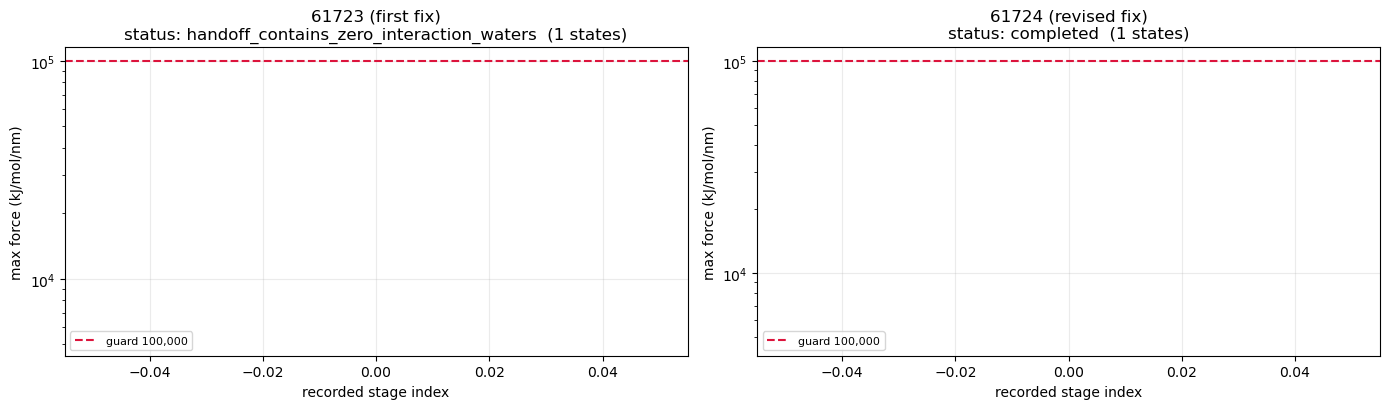

  61723 (first fix)      max force over the whole run: 5,151 kJ/mol/nm (guard 100,000) -> never tripped
  61724 (revised fix)    max force over the whole run: 4,729 kJ/mol/nm (guard 100,000) -> never tripped

  Both jobs stayed far below the 100,000 kJ/mol/nm guard for their entire run.
  That is the point of job 61723: the DYNAMICS were never in trouble. The defect
  was in what got written to disk, and only the topology audit could see it.



In [11]:
# ── Trajectory of the diagnostic through its recorded stages ─────────────────
if HAVE_MPL and jobs:
    fig, axes = plt.subplots(1, len(jobs), figsize=(7.0 * len(jobs), 4.2), squeeze=False)
    for ax, (label, r) in zip(axes[0], jobs.items()):
        forces, pots, names_ = [], [], []
        for s in r["stages"]:
            live = s.get("live_state")
            if not live:
                continue
            f = live.get("max_force_kj_mol_nm")
            p = live.get("potential_kj_mol")
            if f is None or p is None or not math.isfinite(f):
                continue
            forces.append(f)
            pots.append(p)
            names_.append(s.get("stage", ""))
        ax.plot(forces, lw=0.8, color="#4C72B0")
        ax.axhline(r["configuration"]["max_force_kj_mol_nm"], ls="--", color="crimson",
                   label=f"guard {r['configuration']['max_force_kj_mol_nm']:,.0f}")
        ax.set_yscale("log")
        ax.set_xlabel("recorded stage index")
        ax.set_ylabel("max force (kJ/mol/nm)")
        ax.set_title(f"{label}\nstatus: {r['status']}  ({len(forces):,} states)")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

for label, r in jobs.items():
    forces = [s["live_state"]["max_force_kj_mol_nm"] for s in r["stages"]
              if s.get("live_state", {}).get("max_force_kj_mol_nm") is not None]
    if forces:
        print(f"  {label:<22} max force over the whole run: {max(forces):,.0f} kJ/mol/nm "
              f"(guard {r['configuration']['max_force_kj_mol_nm']:,.0f}) -> "
              f"{'never tripped' if max(forces) < r['configuration']['max_force_kj_mol_nm'] else 'TRIPPED'}")
print("""
  Both jobs stayed far below the 100,000 kJ/mol/nm guard for their entire run.
  That is the point of job 61723: the DYNAMICS were never in trouble. The defect
  was in what got written to disk, and only the topology audit could see it.
""")

---
## 5 · Native-MD control ladder

Before concluding anything about Loch, establish that the plain system is stable
under plain MD in both engines. These are the narrowest available diagnostics —
use the narrowest one that covers the question.

| Script | Scope |
|---|---|
| `diagnose_direct_native_md.py` | direct OpenMM native-AMBER MD control |
| `diagnose_native_md.py` | Sire native-AMBER MD control |
| `compare_native_constraints.py` | direct-OpenMM vs Sire constraint construction |
| `diagnose_loch_handoff.py` | short native → Loch → MD stability check |
| `diagnose_uvt1_stability.py` / `.slurm` | exact UVT1 tracing + finalised/reloaded topology audit |
| `diagnose_uvt2_stability.py` / `.slurm` | the five-way saved-NPT isolation above |
| `compare_ludovic_loch_energy.py` | identical-coordinate energy comparison (§1) |

Not diagnostics, and not to be confused with them: `benchmark_loch_batch.py` and
`run_loch_batch_sweep.sh` (Loch batch-size performance), `calibrate_tip3p_300.py`
and `prepare_bulk_tip3p.py` (TIP3P calibration), and
`benchmark_grand_batches.py` / `profile_grand_move.py` /
`test_barostat_transition.py` / `smoke_test_grand.py` (GRAND experiments).

In [12]:
# ── Submission, and the overrides that matter ────────────────────────────────
print(r"""
# ── UVT1 ─────────────────────────────────────────────────────────────────────
sbatch scripts/diagnose_uvt1_stability.slurm
#   default input: $HOME/cry/cry-loch-full/rep1/preparation  (matches the pipeline)

sbatch --export=ALL,REPLICA=2,CYCLES=100,SEED=20260714 scripts/diagnose_uvt1_stability.slurm
sbatch --export=ALL,INPUT_DIR=/path/to/preparation,CYCLES=100,SEED=20260714 \
       scripts/diagnose_uvt1_stability.slurm

# INITIAL_CHUNK_SIZE  default 1000 -> chunks the 10,000 initial attempts for
#                     LOCALISATION at identical total work. Set 10000 to
#                     reproduce the single production call exactly.
#                     (61723 used 1000; 61724 used 10000 — that is the difference
#                      in their configuration blocks above.)
# CYCLES=0            initial-move-only check
# MAX_FORCE           default 100000 kJ/mol/nm; STOPS BEFORE MD once exceeded.
#                     Set 0 only when deliberately tracing through the spike.
# BATCH_SIZE, INITIAL_ATTEMPTS, ATTEMPTS, MD_STEPS also overridable; defaults
# match LochEquilibration.py.

# ── UVT2 five-way array ──────────────────────────────────────────────────────
sbatch scripts/diagnose_uvt2_stability.slurm
""")

print("""What every diagnostic record contains, after every stage:

  * finite positions / velocities / forces / energies, and WHICH atoms are not
  * maximum-force and maximum-speed atom IDENTITY, and its logical water state
  * constraint position and velocity errors, with the offending atom pairs
  * RF preacceptance count and final PME moves
  * how many coordinates the move actually changed
  * logical water-state counts and the active appended-buffer identities
  * MISMATCHES between logical state and the mutable OpenMM charge/LJ parameters

  That last item is the one that found this bug. Recording only energies and
  forces would not have.
""")


# ── UVT1 ─────────────────────────────────────────────────────────────────────
sbatch scripts/diagnose_uvt1_stability.slurm
#   default input: $HOME/cry/cry-loch-full/rep1/preparation  (matches the pipeline)

sbatch --export=ALL,REPLICA=2,CYCLES=100,SEED=20260714 scripts/diagnose_uvt1_stability.slurm
sbatch --export=ALL,INPUT_DIR=/path/to/preparation,CYCLES=100,SEED=20260714 \
       scripts/diagnose_uvt1_stability.slurm

# INITIAL_CHUNK_SIZE  default 1000 -> chunks the 10,000 initial attempts for
#                     LOCALISATION at identical total work. Set 10000 to
#                     reproduce the single production call exactly.
#                     (61723 used 1000; 61724 used 10000 — that is the difference
#                      in their configuration blocks above.)
# CYCLES=0            initial-move-only check
# MAX_FORCE           default 100000 kJ/mol/nm; STOPS BEFORE MD once exceeded.
#                     Set 0 only when deliberately tracing through the spike.
# BATCH_

---
## 6 · Result interpretation table

Where to look first, given what you see. Reproduced from
`skills/loch-ludovic/references/diagnostics.md`.

| Pattern | Most likely layer |
|---|---|
| unsafe at `sampler_bound` | input topology, or Sire/OpenMM construction |
| unsafe after `sphere_deleted` or minimisation | initial sphere deletion, geometry, or minimisation setup |
| large force directly after a move, no MD yet | GCMC trial / PME correction / rollback — inspect ghost state and changed coordinates |
| parameter-state mismatch | Loch logical state and OpenMM `NonbondedForce` are inconsistent |
| inactive ghost has large force **with changed coordinates** | rejected insertion geometry, or bonded ghost terms |
| **active/physical** water has large force, especially after a rejected deletion | overlap, or restored nonbonded coupling ← **the UVT2 incident** |
| constraint error grows only during MD | geometry/constraint integration, not move-state rollback |
| `handoff_contains_zero_interaction_waters` | Sire topology materialization or save/reload failure — **do not run NPT** |
| UVT1 and handoff clean, later NPT control stable | move the diagnosis to UVT2 or production, using the saved boundary inputs |

---
## 7 · Recap

**Energy parity is established.** 0.001 kJ/mol on 8.9 × 10⁸ — the Sire/Loch
construction is the same potential as Ludovic's direct OpenMM one. That covers the
force field, cutoffs, switching, dispersion, Ewald tolerance and constraints. It
does **not** cover the sampler; notebook 04 tests that.

**The UVT2 failure was a topology bug, not a dynamics bug.** Located by five
one-variable controls from a single saved boundary. NPT, the 2 fs timestep,
minimisation, the Cα restraints and constraint drift are all excluded by
experiment, not by argument.

**The mechanism, in one sentence.** Loch 2025.2 changes an accepted buffer water's
charge and LJ only in the live OpenMM force, so a handoff that saves the Sire
topology writes zero-interaction waters that NPT then propagates for 2 ns until
they overlap, and the next GCMC stage's *rejected* deletion restores their
parameters and detonates.

**The fix is a topology invariant enforced after removal, not an activation before
it.** Job 61723 is the proof that the difference matters: UVT1 ran clean through
135,000 attempts and still produced a wrong handoff.

**Four things to carry forward.**

1. **A stage completing proves nothing about its output.** Verify by artefact.
2. **Record identity, not just magnitude.** "Max force 1.8 × 10⁷" is a symptom;
   "on an active physical water at slot 18801" is a diagnosis.
3. **A rejected move can still break the system.** Zero insertions and zero
   deletions is not a defence.
4. **Minimisation succeeding is not correctness.** A non-interacting water, or a
   ligand parked in bulk solvent, both minimise beautifully. The loud failure is
   safer than the quiet one — the same lesson appears again in notebook 06 §3.

**Next:** notebook 08 asks whether the GCMC waters this pipeline places actually
improve pose prediction. The answer is instructive and mostly negative.